# Лабораториска Вежба 2 – Регресија
### Diamond Price Prediction

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings

warnings.filterwarnings('ignore')
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNet, BayesianRidge
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')## 1. Вчитување

In [19]:
# Вчитување на датасетот
# df = kagglehub.load_dataset(
#     KaggleDatasetAdapter.PANDAS,
#     "swatikhedekar/price-prediction-of-diamond",
#     ""
# )

df = sns.load_dataset('diamonds')

# Кодирање на категориски атрибути (cut, color, clarity)
for col in ['cut', 'color', 'clarity']:
    df[col] = LabelEncoder().fit_transform(df[col])  #LabelEncoder доделува цел број на секоја категорија.

X = df.drop(columns=['price']).values
y = df['price'].values
feature_names = df.drop(columns=['price']).columns.tolist()

print(df.head())
print(f'\nОблик: {df.shape}')
print(f'Атрибути: {feature_names}')

   carat  cut  color  clarity  depth  table  price     x     y     z
0   0.23    2      1        3   61.5   55.0    326  3.95  3.98  2.43
1   0.21    3      1        2   59.8   61.0    326  3.89  3.84  2.31
2   0.23    1      1        4   56.9   65.0    327  4.05  4.07  2.31
3   0.29    3      5        5   62.4   58.0    334  4.20  4.23  2.63
4   0.31    1      6        3   63.3   58.0    335  4.34  4.35  2.75

Облик: (53940, 10)
Атрибути: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


## 2. Визуелизации и нормализација

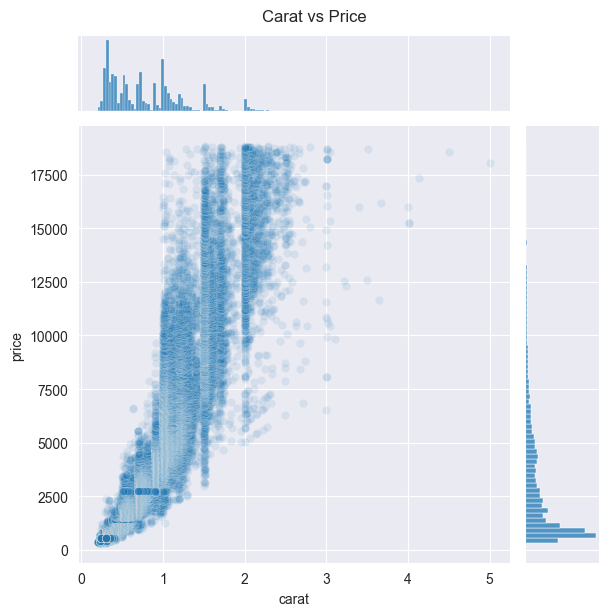

In [20]:
# Jointplot - carat vs price (најсилна корелација)
sns.jointplot(data=df, x='carat', y='price', kind='scatter', alpha=0.1)
plt.suptitle('Carat vs Price', y=1.02)
plt.show()

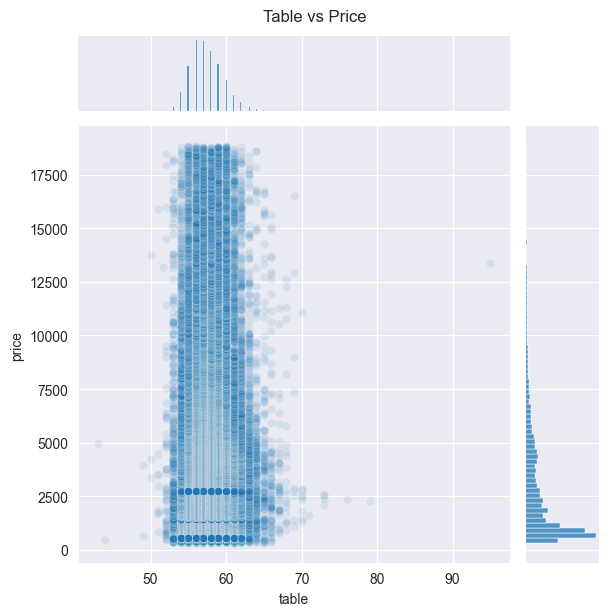

In [21]:
# Jointplot - table vs price
sns.jointplot(data=df, x='table', y='price', kind='scatter', alpha=0.1)
plt.suptitle('Table vs Price', y=1.02)
plt.show()

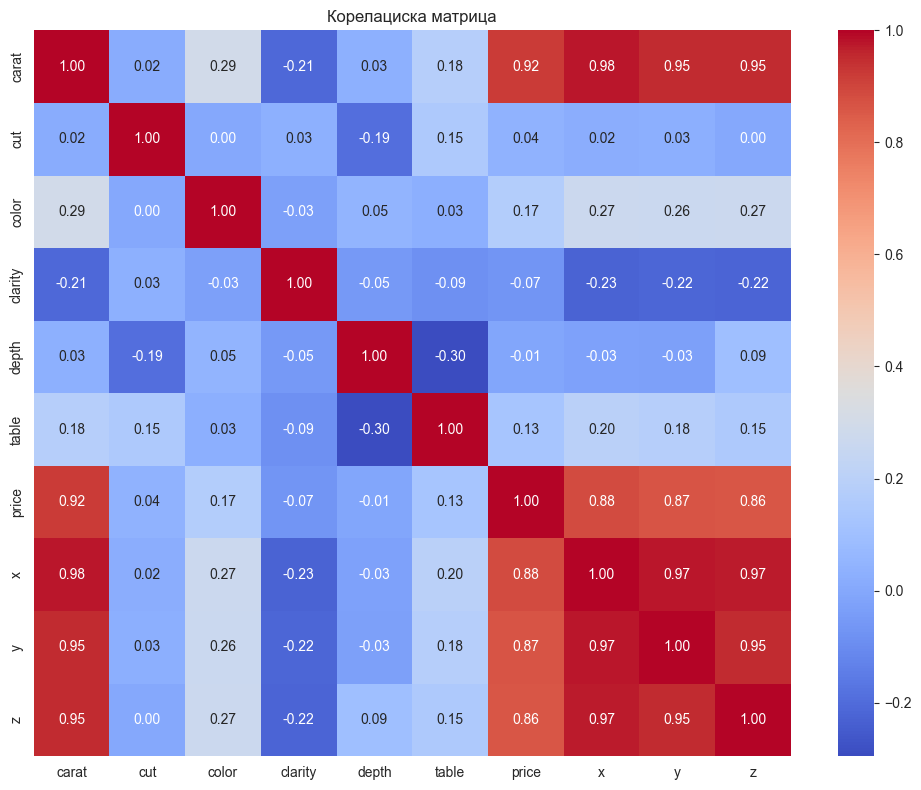

In [22]:
# Корелациска матрица
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корелациска матрица')
plt.tight_layout()
plt.show()

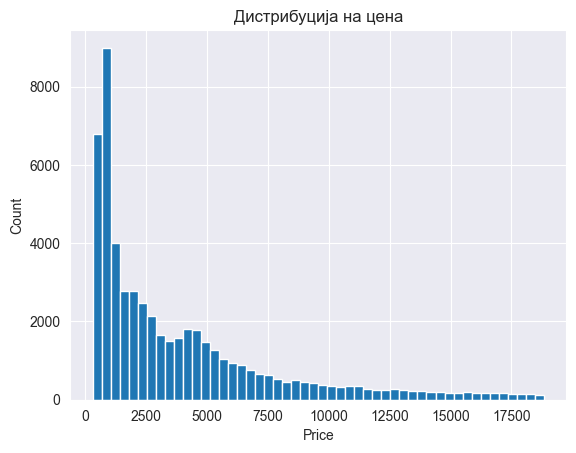

In [23]:
# Дистрибуција на целната променлива
plt.hist(y, bins=50)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Дистрибуција на цена')
plt.show()

In [24]:
# Min-max нормализација на атрибутите
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

## 3. Поделба и тренирање

In [25]:
split = int(0.8 * len(X_norm))
train_x, test_x = X_norm[:split], X_norm[split:]
train_y, test_y = y[:split], y[split:]

# RidgeCV и LassoCV автоматски го наоѓаат оптималниот alpha преку cross-validation
models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
    'LassoCV': LassoCV(cv=5, max_iter=10000),
    'ElasticNet': ElasticNet(max_iter=10000),
    'BayesianRidge': BayesianRidge()
}

for model in models.values():
    model.fit(train_x, train_y)

## 4. Споредба

In [26]:
# MSE на тест множеството
for name, model in models.items():
    mse = mean_squared_error(test_y, model.predict(test_x))
    print(f'{name}: MSE = {mse:.2f}')

# Оптимален alpha за RidgeCV и LassoCV
print(f'\nRidgeCV alpha: {models["RidgeCV"].alpha_}')
print(f'LassoCV alpha: {models["LassoCV"].alpha_:.6f}')

LinearRegression: MSE = 609314.60
RidgeCV: MSE = 644452.49
LassoCV: MSE = 750580.77
ElasticNet: MSE = 6359618.41
BayesianRidge: MSE = 609559.09

RidgeCV alpha: 1.0
LassoCV alpha: 5.322578


In [27]:
# Коефициенти по модел
for name, model in models.items():
    print(f'\n{name}:')
    for fname, coef in zip(feature_names, model.coef_):
        print(f'  {fname}: {coef:.4f}')


LinearRegression:
  carat: 50215.4218
  cut: 323.7159
  color: -1777.4635
  clarity: 2253.0709
  depth: -5790.1871
  table: -5539.6965
  x: -10341.7478
  y: 3393.2212
  z: 672.8091

RidgeCV:
  carat: 47569.3528
  cut: 328.0045
  color: -1749.7206
  clarity: 2264.7179
  depth: -5212.1910
  table: -5404.6590
  x: -7166.5683
  y: 1115.6123
  z: -930.8447

LassoCV:
  carat: 39254.0343
  cut: 268.9461
  color: -1583.9728
  clarity: 2261.7679
  depth: -0.0000
  table: -941.3767
  x: 0.0000
  y: 0.0000
  z: -0.0000

ElasticNet:
  carat: 795.1509
  cut: 79.1198
  color: 355.6294
  clarity: -117.2579
  depth: -4.2761
  table: 46.0221
  x: 813.4162
  y: 147.0568
  z: 167.5055

BayesianRidge:
  carat: 50194.8665
  cut: 323.7687
  color: -1777.2543
  clarity: 2253.1732
  depth: -5782.8116
  table: -5538.8467
  x: -10304.9707
  y: 3358.4858
  z: 617.0387


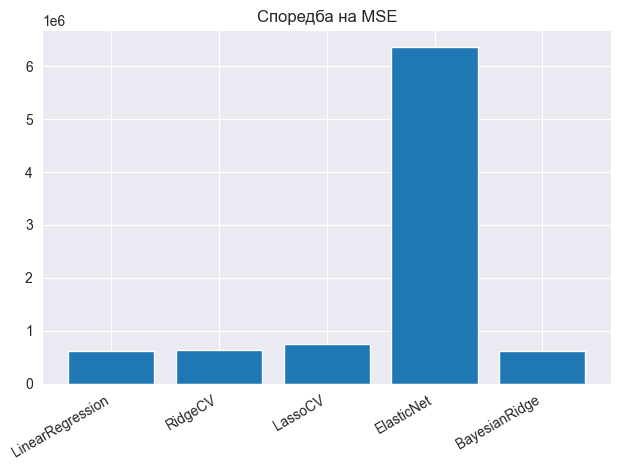

In [29]:
mses = [mean_squared_error(test_y, m.predict(test_x)) for m in models.values()]
plt.bar(models.keys(), mses)
plt.title('Споредба на MSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ElasticNet комбинира L1 + L2 регуларизација,
# но со default параметри (alpha=1.0, l1_ratio=0.5)
# кои се премногу агресивни за овој датасет —
# ги „казнува" коефициентите премногу и губи важна информација.